## Project: Stock Market Trend Analysis and Prediction
### Stock Market Data From Yahoo Finance (using yfinance python library)

In [1]:
!pip install -r https://raw.githubusercontent.com/brittojo7n/BigDataProject-StockMarketTrendAnalysisAndPrediction/refs/heads/main/requirements.txt

In [2]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline


In [3]:
from pandas_datareader import DataReader
from datetime import datetime
from __future__ import division

#### Section 1 - Basic Analysis of Stock Information


In [4]:
!pip install yfinance --upgrade --no-cache-dir

In [5]:
import yfinance as yf
from datetime import datetime, timedelta
import time

tech_list = ['AAPL', 'GOOGL', 'MSFT', 'AMZN']

end = datetime.now()
start = end - timedelta(days=365*5)

stock_data = {}

for stock in tech_list:
    success = False
    for attempt in range(3):
        try:
            print(f"Fetching data for {stock} (Attempt {attempt + 1})...")
            data = yf.download(stock, start=start, end=end, threads=False)
            if not data.empty:
                stock_data[stock] = data
                success = True
                break
            else:
                print(f"No data returned for {stock}, retrying...")
        except Exception as e:
            print(f"Error fetching data for {stock}: {e}")
        time.sleep(5)

    if not success:
        print(f"Failed to fetch data for {stock} after 3 attempts.")

AAPL = stock_data.get('AAPL')
if AAPL is not None:
    print("\nAAPL Stock Data:")
    print(AAPL.head())
else:
    print("\nData for AAPL is not available.")

Fetching data for AAPL (Attempt 1)...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Fetching data for GOOGL (Attempt 1)...
Fetching data for MSFT (Attempt 1)...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Fetching data for AMZN (Attempt 1)...

AAPL Stock Data:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-05-08  75.465797  75.519332  74.044716  74.373221  133838400
2020-05-11  76.653244  77.149644  74.762519  74.971792  145946400
2020-05-12  75.777252  77.792074  75.655584  77.339465  162301200
2020-05-13  74.862297  76.881990  73.781885  75.957309  200622400
2020-05-14  75.322220  75.383054  73.373096  74.098240  158929200


Note: While using `globals()` to name DataFrames isn’t recommended for maintainability, it provides a quick way to prototype. Let’s explore the Apple (AAPL) DataFrame to get familiar with its structure.

In [6]:
AAPL.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-05-08,75.465797,75.519332,74.044716,74.373221,133838400
2020-05-11,76.653244,77.149644,74.762519,74.971792,145946400
2020-05-12,75.777252,77.792074,75.655584,77.339465,162301200
2020-05-13,74.862297,76.881990,73.781885,75.957309,200622400
2020-05-14,75.322220,75.383054,73.373096,74.098240,158929200


In [7]:
AAPL.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03
mean,162.740862,164.411386,160.882203,162.576096,8.179135e+07
std,39.311784,39.522354,39.008465,39.229761,4.233459e+07
min,74.862297,74.923149,73.051895,73.085966,4.931556e+06
25%,134.335052,136.432023,132.795994,134.311994,5.296460e+07
50%,160.490265,162.437939,158.208000,160.008733,7.129110e+07
75%,186.620457,188.201162,185.248306,186.707224,9.704310e+07
max,258.735504,259.814335,257.347047,257.906429,3.743368e+08


In [8]:
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2020-05-08 to 2025-05-07
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1256 non-null   float64
 1   (High, AAPL)    1256 non-null   float64
 2   (Low, AAPL)     1256 non-null   float64
 3   (Open, AAPL)    1256 non-null   float64
 4   (Volume, AAPL)  1256 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


Now that we've seen the DataFrame, let's go ahead and plot out the volume and closing price of the AAPL(Apple) stocks.

<Axes: xlabel='Date'>

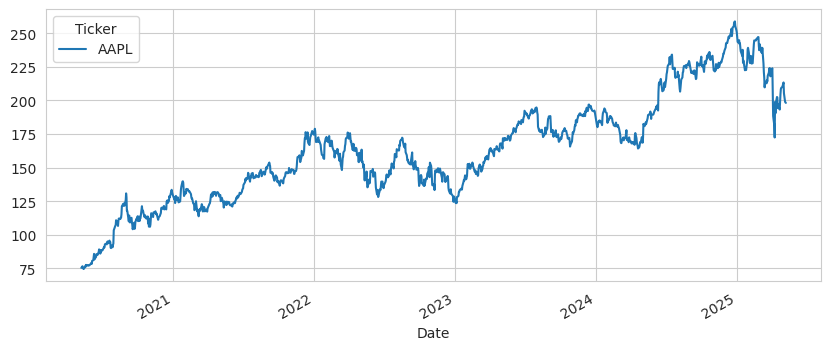

In [9]:
AAPL['Close'].plot(legend=True, figsize=(10,4))

<Axes: xlabel='Date'>

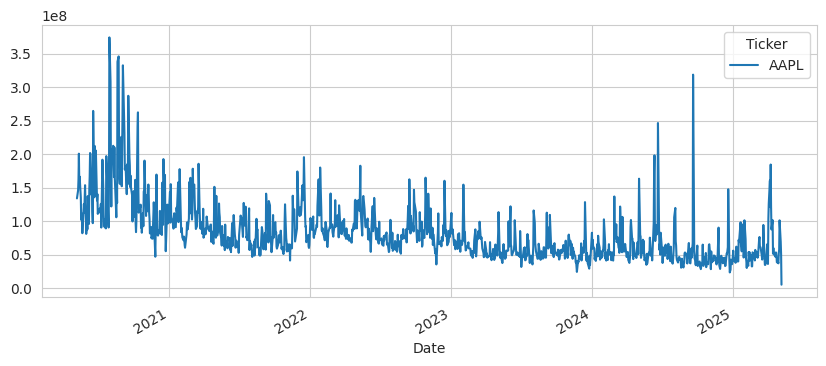

In [10]:
AAPL['Volume'].plot(legend=True, figsize=(10,4))

In [11]:
import pandas as pd

MA_day = [10, 20, 50, 100]

for ma in MA_day:
    column_name = f"MA for {ma} days"
    AAPL[column_name] = AAPL['Close'].rolling(window=ma).mean()

print(AAPL.head())


Price           Close       High        Low       Open     Volume  \
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL   
Date                                                                
2020-05-08  75.465797  75.519332  74.044716  74.373221  133838400   
2020-05-11  76.653244  77.149644  74.762519  74.971792  145946400   
2020-05-12  75.777252  77.792074  75.655584  77.339465  162301200   
2020-05-13  74.862297  76.881990  73.781885  75.957309  200622400   
2020-05-14  75.322220  75.383054  73.373096  74.098240  158929200   

Price      MA for 10 days MA for 20 days MA for 50 days MA for 100 days  
Ticker                                                                   
Date                                                                     
2020-05-08            NaN            NaN            NaN             NaN  
2020-05-11            NaN            NaN            NaN             NaN  
2020-05-12            NaN            NaN            NaN             NaN  
202

Now, lets plot all the additional Moving Averages for AAPL stock

<Axes: xlabel='Date'>

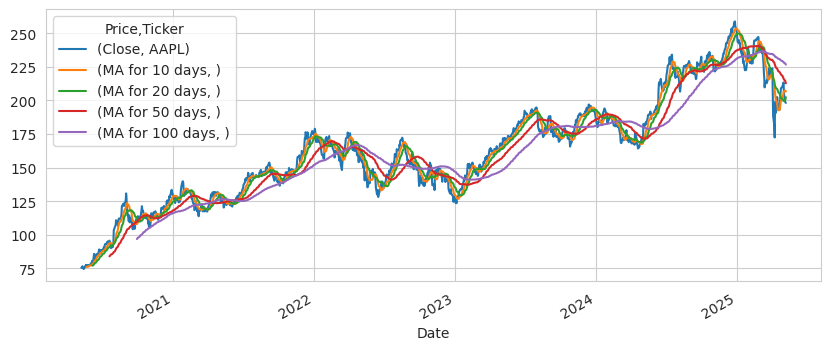

In [12]:
AAPL[['Close','MA for 10 days','MA for 20 days','MA for 50 days','MA for 100 days']].plot(subplots=False,figsize=(10,4))

#### Section 2 - Daily Return Analysis
We are now analyzing the risk of the stock. In order to do so, we need to take a closer look at the daily changes of the stock, and not just its absolute value. Let's go ahead and use pandas to retrieve the daily returns for the APPL stock.

<Axes: xlabel='Date'>

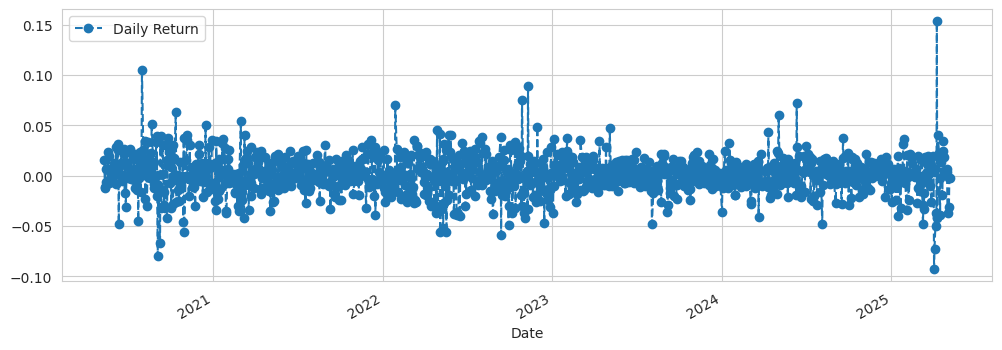

In [13]:
AAPL['Daily Return'] = AAPL['Close'].pct_change()
AAPL['Daily Return'].plot(figsize=(12,4), legend=True, linestyle='--', marker='o')

To inspect the distribution of average daily returns, generate a seaborn plot combining a histogram with its KDE overlay for a clear, professional visualization.

<Axes: >

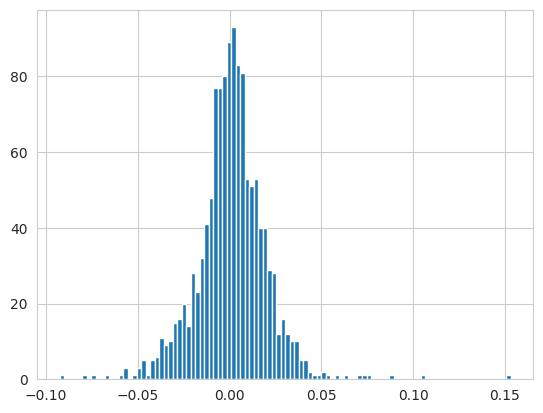

In [14]:
AAPL['Daily Return'].hist(bins=100)

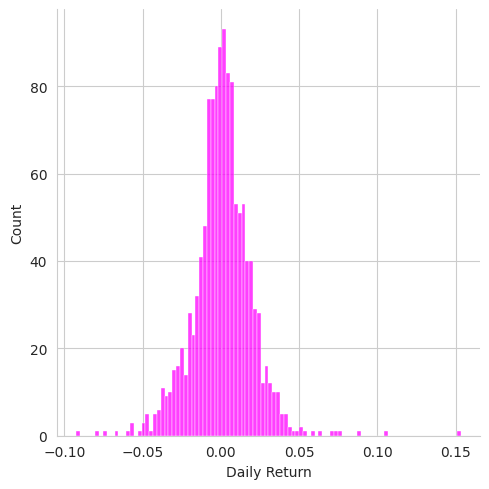

In [15]:
sns.displot(AAPL['Daily Return'].dropna(), bins=100, color='magenta')

To analyze returns for all tickers, aggregate each DataFrame’s `[Close]` column into a single combined DataFrame.

In [16]:
closingprice_df = pd.DataFrame()

for stock in tech_list:
    try:
        data = yf.download(stock, start=start, end=end)
        closingprice_df[stock] = data['Close']
    except Exception as e:
        print(f"Failed to fetch data for {stock}: {e}")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [17]:
closingprice_df.head(10)

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2020-05-08,75.465767,68.887650,176.771744,118.980499
2020-05-11,76.653259,69.845566,178.743546,120.449997
2020-05-12,75.777245,68.431831,174.694687,117.847504
2020-05-13,74.862282,67.095711,172.052856,118.396004
2020-05-14,75.322220,67.520187,172.799438,119.442497
2020-05-15,74.876907,68.326332,175.316833,120.488998
2020-05-18,76.641090,68.929451,176.991928,121.313004
2020-05-19,76.198227,68.393021,175.766724,122.466499
2020-05-20,77.680138,70.122742,178.204742,124.897003


Now that we have all the closing prices, let's go ahead and get the daily return for all the stocks, like we did for the APPL stock.

In [18]:
tech_returns = closingprice_df.pct_change()

In [19]:
tech_returns.head()

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2020-05-08,NaN,NaN,NaN,NaN
2020-05-11,0.015736,0.013905,0.011155,0.012351
2020-05-12,-0.011428,-0.020241,-0.022652,-0.021606
2020-05-13,-0.012074,-0.019525,-0.015123,0.004654
2020-05-14,0.006144,0.006326,0.004339,0.008839


Now we can compare the daily percentage return of two stocks to check how correlated. First let's see a stock compared to itself.

##### GOOGL is a Alphabet Inc Class A Stock.

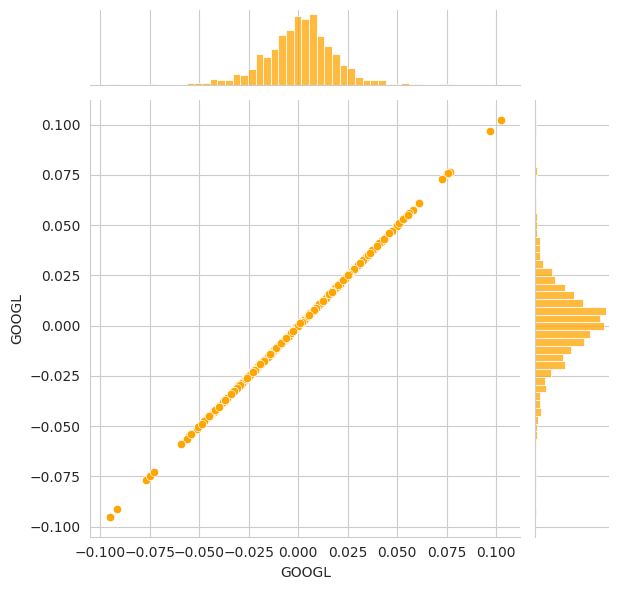

In [20]:
import seaborn as sns
sns.jointplot(x='GOOGL', y='GOOGL', data=tech_returns, kind='scatter', color='orange')

So now we can see that if two stocks are perfectly (and positivley) correlated with each other a linear relationship bewteen its daily return values should occur.

So let's go ahead and compare Google and Amazon the same way.

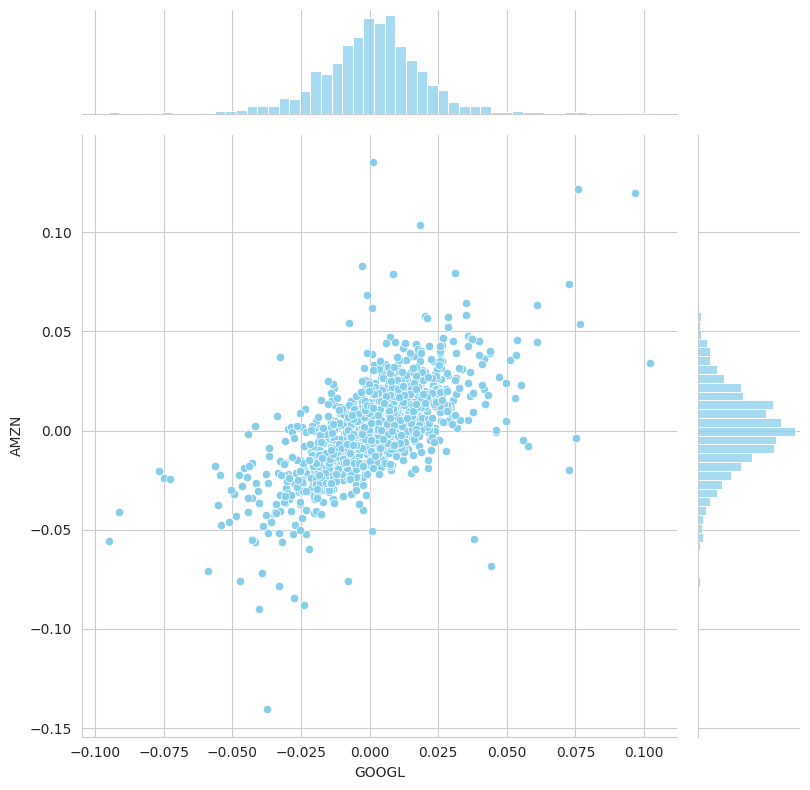

In [21]:
import seaborn as sns
sns.jointplot(x='GOOGL', y='AMZN', data=tech_returns, kind='scatter', height=8, color='skyblue')

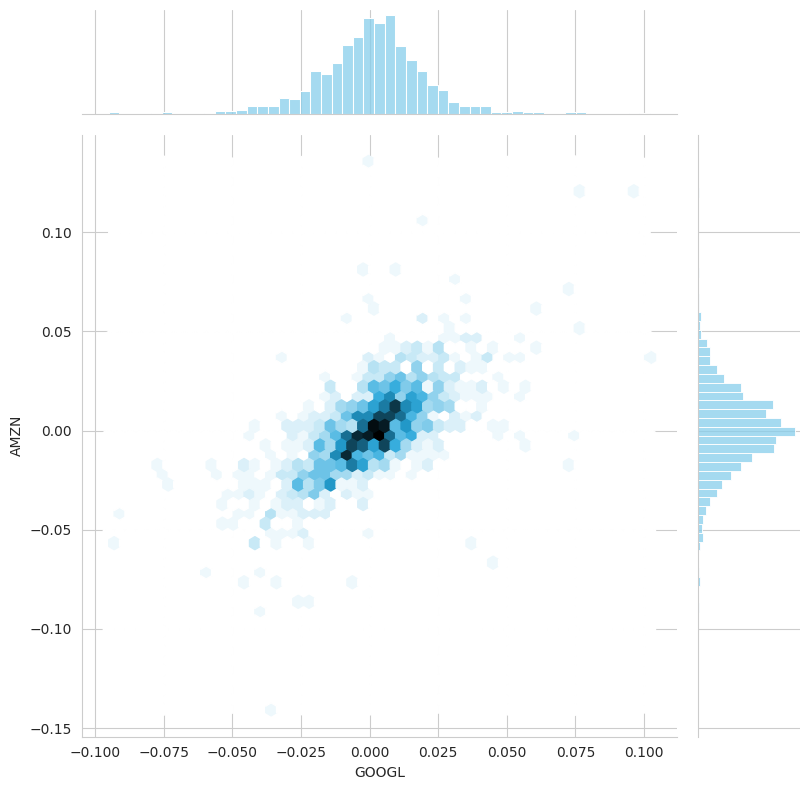

In [22]:
import seaborn as sns
sns.jointplot(x='GOOGL', y='AMZN', data=tech_returns, kind='hex', height=8, color='skyblue')

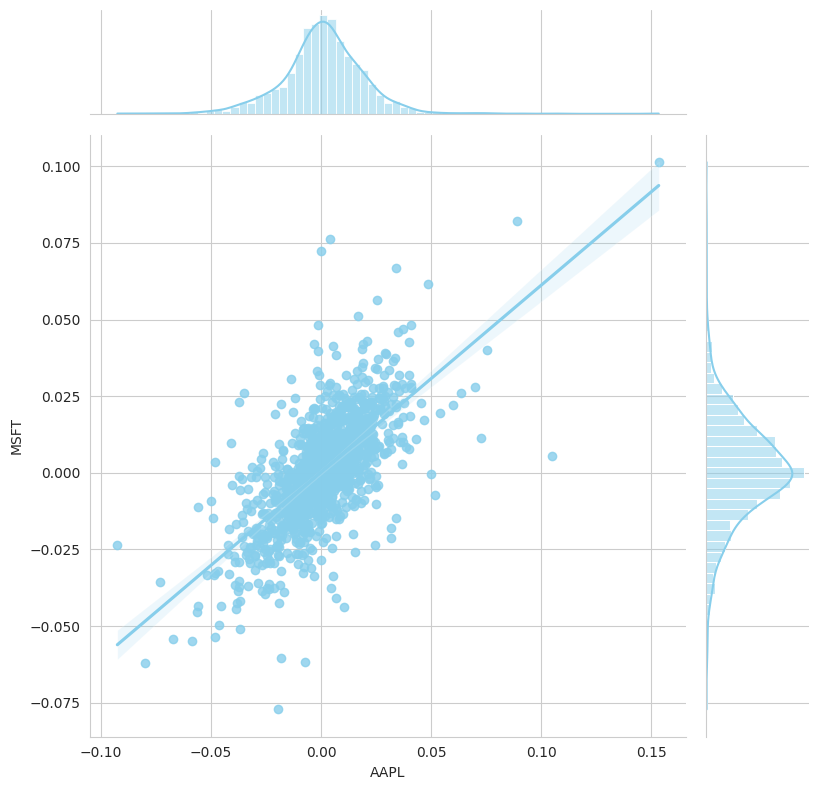

In [23]:
import seaborn as sns
sns.jointplot(x='AAPL', y='MSFT', data=tech_returns, kind='reg', height=8, color='skyblue')

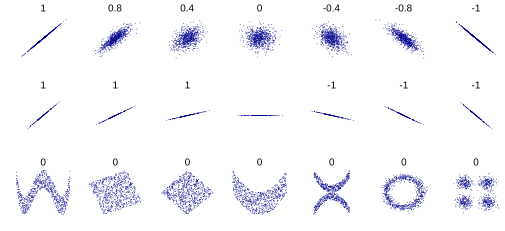

In [24]:
from IPython.display import SVG
SVG(url='http://upload.wikimedia.org/wikipedia/commons/d/d4/Correlation_examples2.svg')

Seaborn and Pandas make it very easy to repeat this comparison analysis for every possible combination of stocks in our technology stock ticker list. We can use sns.pairplot() to automatically create this plot

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


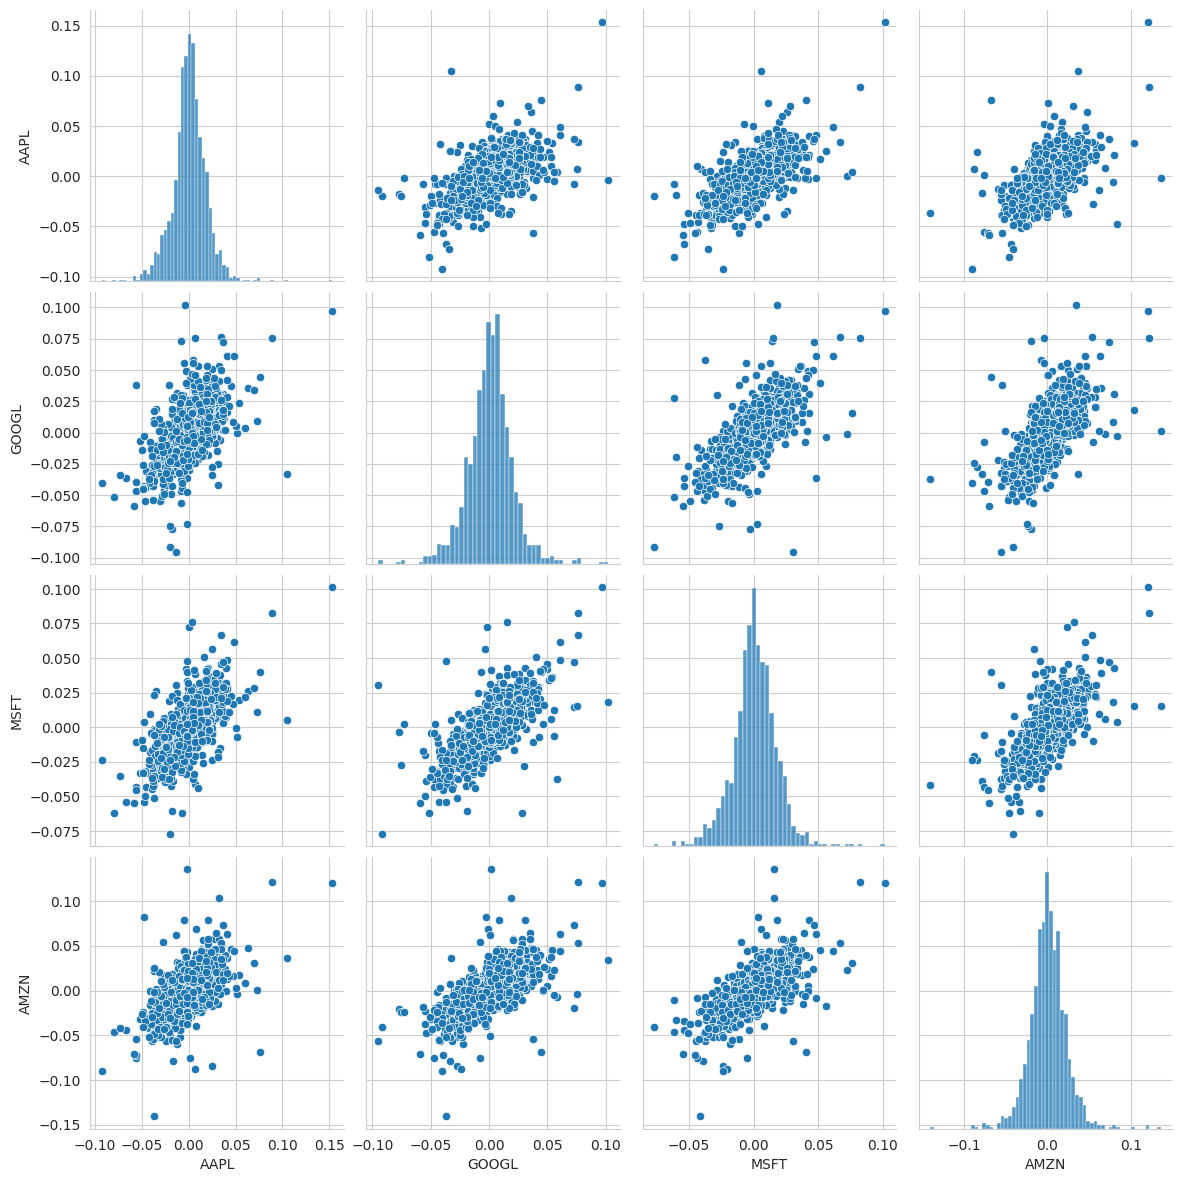

In [25]:
sns.pairplot(tech_returns.dropna(),size=3)

This pairwise plot reveals daily return relationships across all stocks, highlighting a notable correlation between Google and Amazon. While sns.pairplot() is great for quick insights, sns.PairGrid() lets you fully customize each subplot—diagonal, upper, and lower panels—for more control.

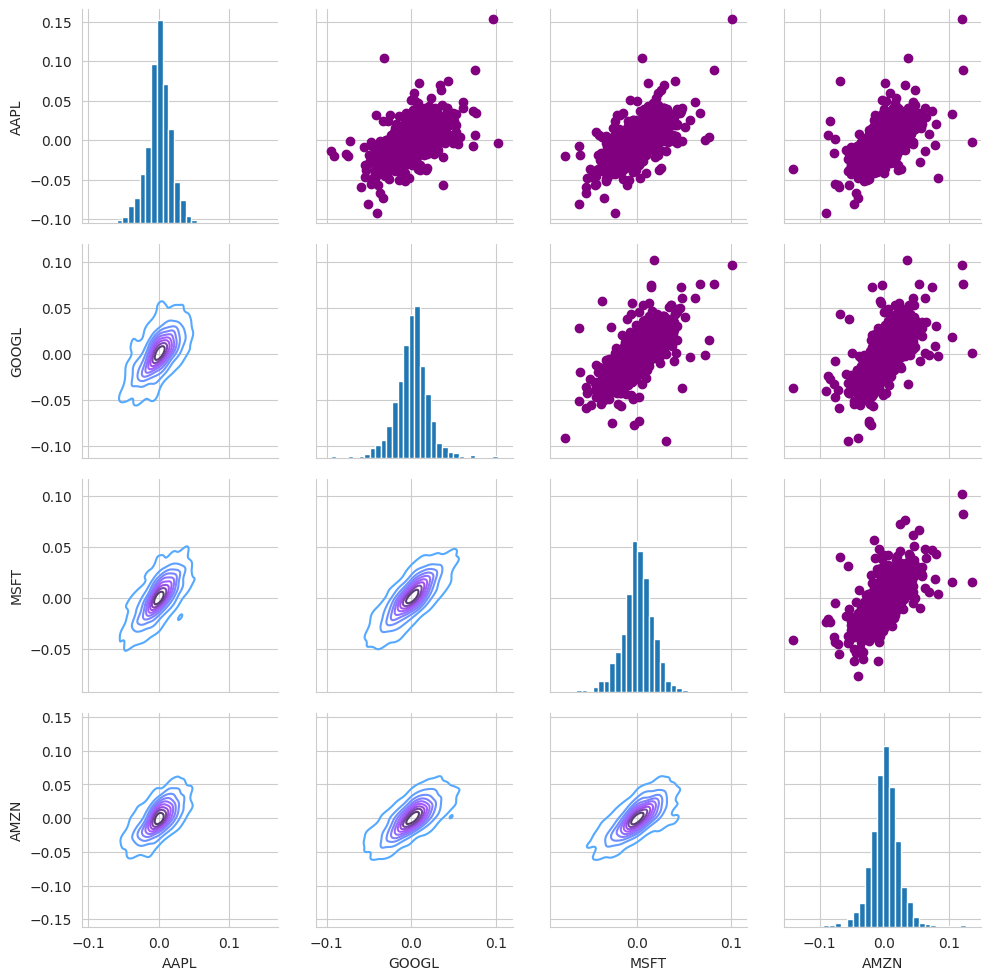

In [26]:
returns_fig = sns.PairGrid(tech_returns.dropna())

returns_fig.map_upper(plt.scatter,color='purple')

returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

returns_fig.map_diag(plt.hist,bins=30)

We can also analyze the correlation of the closing prices using this exact same technique. Here it is shown, the code repeated from above with the exception of the DataFrame called.

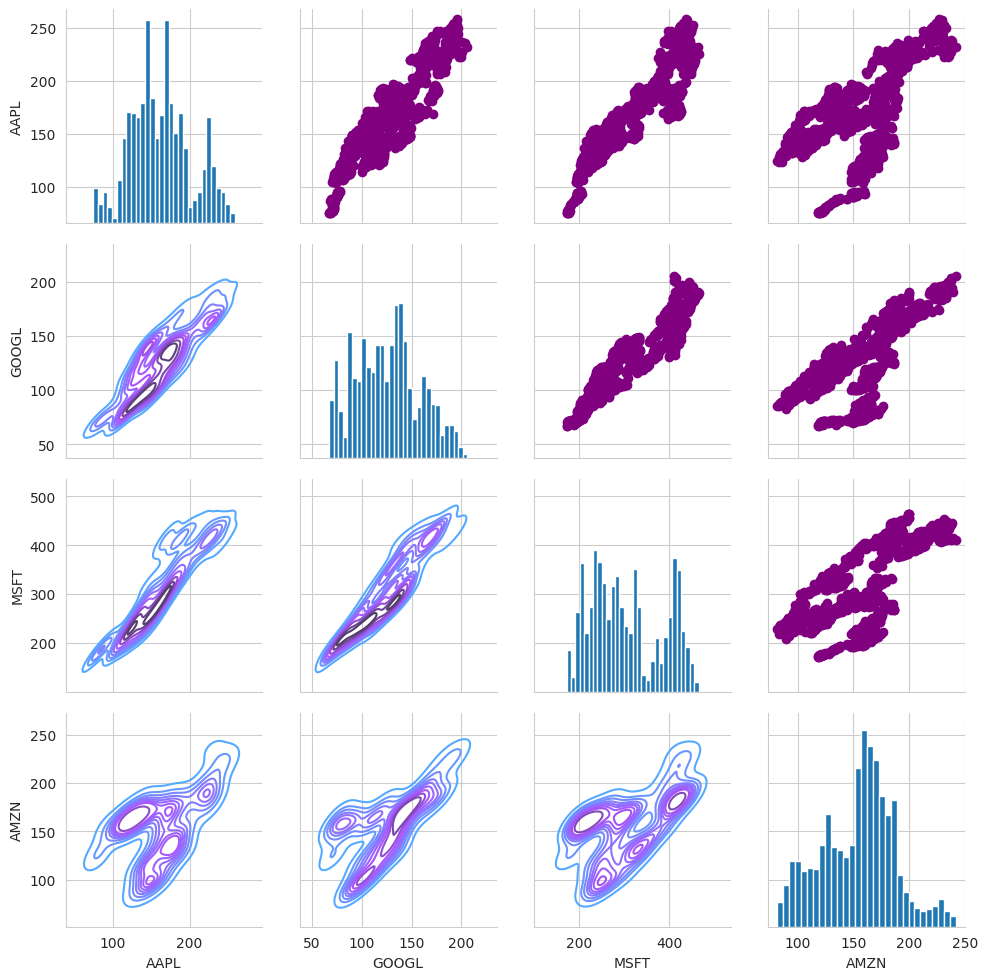

In [27]:
returns_fig = sns.PairGrid(closingprice_df.dropna())
returns_fig.map_upper(plt.scatter,color='purple')
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')
returns_fig.map_diag(plt.hist,bins=30)

Finally, we can also do a correlation plot, to get actual numerical values for the correlation between the stocks' daily return values. By comparing the closing prices, we see an interesting relationship between Google and Amazon stocks.

<Axes: >

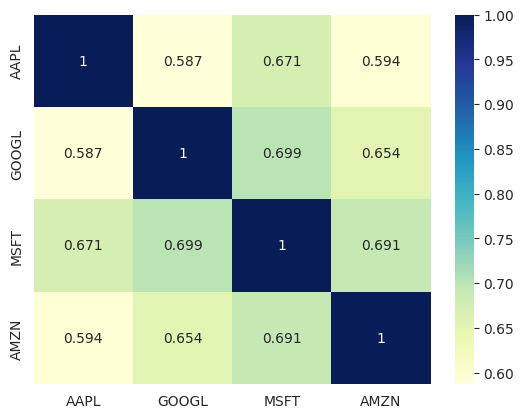

In [28]:
sns.heatmap(tech_returns.corr(),annot=True,fmt=".3g",cmap='YlGnBu')

<Axes: >

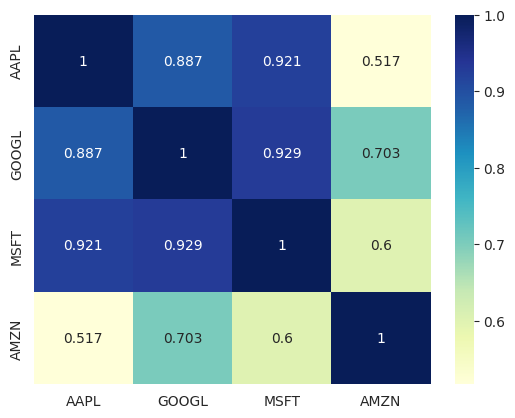

In [29]:
sns.heatmap(closingprice_df.corr(),annot=True,fmt=".3g",cmap='YlGnBu')

Analysis confirms a strong daily-return correlation between Amazon and Google, with all tech stocks exhibiting positive alignment. We will now proceed to a detailed risk assessment.

### Risk Analysis

In [30]:
rets = tech_returns.dropna()

In [31]:
rets.head()

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2020-05-11,0.015736,0.013905,0.011155,0.012351
2020-05-12,-0.011428,-0.020241,-0.022652,-0.021606
2020-05-13,-0.012074,-0.019525,-0.015123,0.004654
2020-05-14,0.006144,0.006326,0.004339,0.008839
2020-05-15,-0.005912,0.011939,0.014568,0.008762


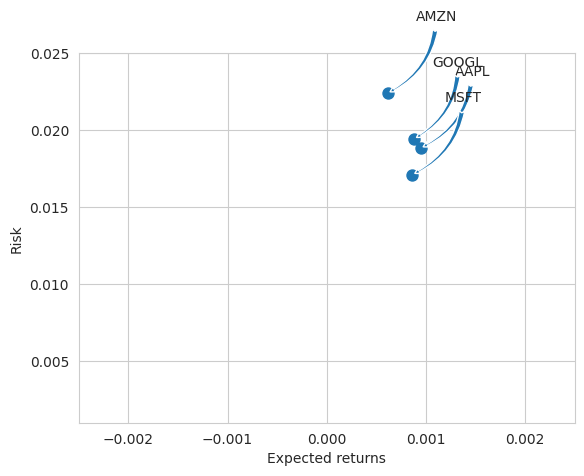

In [32]:
area = np.pi*20

plt.scatter(rets.mean(),rets.std(),s=area)

plt.xlim([-0.0025,0.0025])
plt.ylim([0.001,0.025])

plt.xlabel('Expected returns')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(
        label,
        xy = (x, y), xytext = (50, 50),
        textcoords = 'offset points', ha = 'right', va = 'bottom',
        arrowprops = dict(arrowstyle = 'fancy', connectionstyle = 'arc3,rad=-0.3'))

By looking at the scatter plot we can say these stocks have lower risk and positive expected returns.

### Value at Risk

### Value at Risk (VaR) Using the Bootstrap Method

VaR estimates the potential loss in value of a stock at a given confidence level. The bootstrap method calculates VaR by resampling historical daily returns and determining the desired quantile—offering a flexible, data-driven risk assessment without assuming a specific return distribution.

We’ll apply this method to Apple’s daily returns to estimate potential downside risk.

<ipython-input-33-ca28547d8edc>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(AAPL['Daily Return'].dropna(),bins=100,color='purple')


<Axes: xlabel='Daily Return', ylabel='Density'>

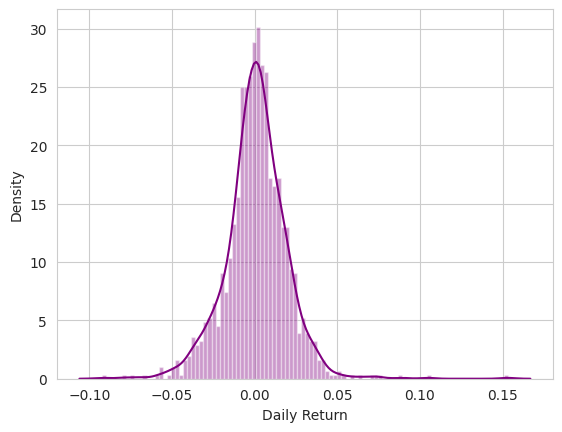

In [33]:
sns.distplot(AAPL['Daily Return'].dropna(),bins=100,color='purple')

Now we can use quantile to get the risk value for the stock.

In [34]:
rets["AAPL"].quantile(0.05)

np.float64(-0.030003570518611567)

The 0.05 empirical quantile of daily returns is at -0.016. That means that with 95% confidence, our worst daily loss will not exceed 1.6%. If we have a 1 million dollar investment, our one-day 5% VaR is 0.016 * 1,000,000 = $16,000.

In [35]:
rets["AMZN"].quantile(0.05)

np.float64(-0.03324062530431055)

In [36]:
rets["GOOGL"].quantile(0.05)

np.float64(-0.030742038485040868)

In [37]:
rets["MSFT"].quantile(0.05)

np.float64(-0.026973248305178277)

### Value at Risk Using the Monte Carlo Method

The Monte Carlo method simulates a range of possible future stock prices under random market conditions to estimate risk. We use Geometric Brownian Motion (GBM), a stochastic process assuming prices follow a random walk—aligned with the Efficient Market Hypothesis (EMH), which states that past price data cannot reliably predict future movements. This approach provides a robust framework for assessing potential portfolio losses over time.


In [38]:
rets.head()

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2020-05-11,0.015736,0.013905,0.011155,0.012351
2020-05-12,-0.011428,-0.020241,-0.022652,-0.021606
2020-05-13,-0.012074,-0.019525,-0.015123,0.004654
2020-05-14,0.006144,0.006326,0.004339,0.008839
2020-05-15,-0.005912,0.011939,0.014568,0.008762


In [39]:
days = 365
dt = 1/days
mu = rets.mean()['GOOGL']
sigma = rets.std()['GOOGL']

Defining a function that uses the starting price, number of days, and our calculated mean (mu) and volatility (sigma) to simulate future stock prices.










In [40]:
def stock_monte_carlo(start_price,days,mu,sigma):
    price = np.zeros(days)
    price[0] = start_price

    shock = np.zeros(days)
    drift = np.zeros(days)

    for x in range(1,days):
        shock[x] = np.random.normal(loc=mu * dt, scale=sigma * np.sqrt(dt))
        drift[x] = mu * dt
        price[x] = price[x-1] + (price[x-1] * (drift[x] + shock[x]))
    return price

In [41]:
print(closingprice_df['GOOGL'].head())

Date
2020-05-08    68.887650
2020-05-11    69.845566
2020-05-12    68.431831
2020-05-13    67.095711
2020-05-14    67.520187
Name: GOOGL, dtype: float64


Text(0.5, 1.0, 'Monte Carlo Analysis for Google')

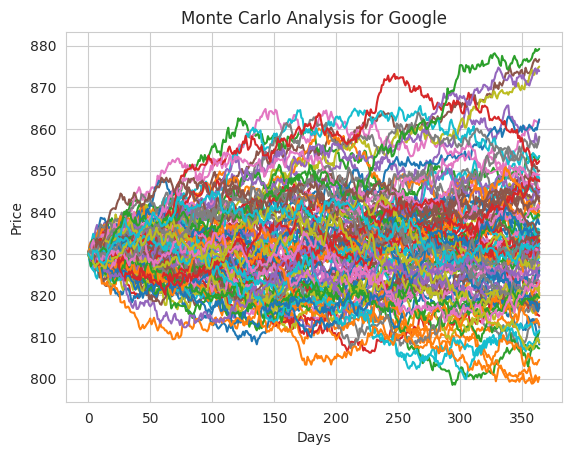

In [42]:
start_price = 830.09

for run in range(100):
    plt.plot(stock_monte_carlo(start_price, days, mu, sigma))

plt.xlabel("Days")
plt.ylabel("Price")
plt.title('Monte Carlo Analysis for Google')

In [43]:
print(closingprice_df['AMZN'].head())

Date
2020-05-08    118.980499
2020-05-11    120.449997
2020-05-12    117.847504
2020-05-13    118.396004
2020-05-14    119.442497
Name: AMZN, dtype: float64


Text(0.5, 1.0, 'Monte Carlo Analysis for Amazon')

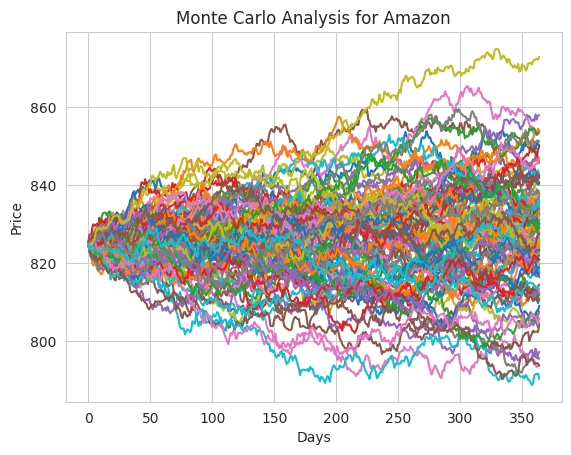

In [44]:
start_price = 824.95

for run in range(100):
    plt.plot(stock_monte_carlo(start_price, days, mu, sigma))

plt.xlabel("Days")
plt.ylabel("Price")
plt.title('Monte Carlo Analysis for Amazon')

In [45]:
AAPL.head()

Price,Close,High,Low,Open,Volume,MA for 10 days,MA for 20 days,MA for 50 days,MA for 100 days,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2020-05-08,75.465797,75.519332,74.044716,74.373221,133838400,NaN,NaN,NaN,NaN,NaN
2020-05-11,76.653244,77.149644,74.762519,74.971792,145946400,NaN,NaN,NaN,NaN,0.015735
2020-05-12,75.777252,77.792074,75.655584,77.339465,162301200,NaN,NaN,NaN,NaN,-0.011428
2020-05-13,74.862297,76.881990,73.781885,75.957309,200622400,NaN,NaN,NaN,NaN,-0.012074
2020-05-14,75.322220,75.383054,73.373096,74.098240,158929200,NaN,NaN,NaN,NaN,0.006144


Text(0.5, 1.0, 'Monte Carlo Analysis for Apple')

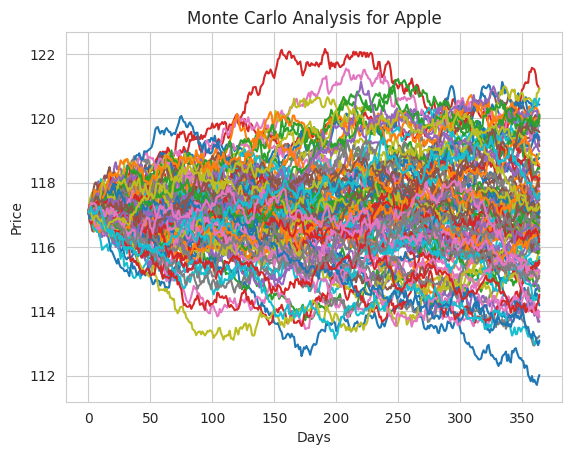

In [46]:
start_price = 117.10

for run in range(100):
    plt.plot(stock_monte_carlo(start_price, days, mu, sigma))

plt.xlabel("Days")
plt.ylabel("Price")
plt.title('Monte Carlo Analysis for Apple')

In [47]:
print(closingprice_df['MSFT'].head())


Date
2020-05-08    176.771744
2020-05-11    178.743546
2020-05-12    174.694687
2020-05-13    172.052856
2020-05-14    172.799438
Name: MSFT, dtype: float64


Text(0.5, 1.0, 'Monte Carlo Analysis for Microsoft')

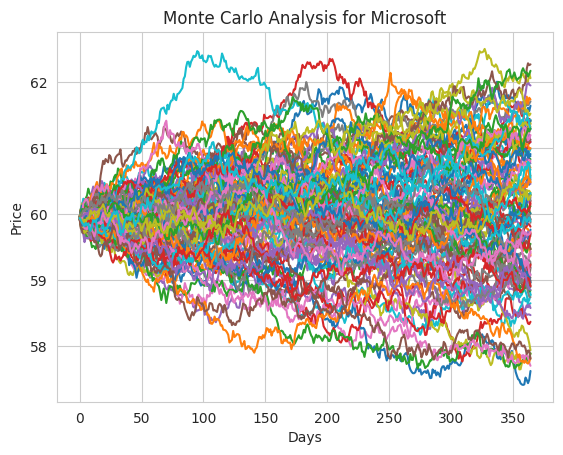

In [48]:
start_price = 59.94

for run in range(100):
    plt.plot(stock_monte_carlo(start_price, days, mu, sigma))

plt.xlabel("Days")
plt.ylabel("Price")
plt.title('Monte Carlo Analysis for Microsoft')

Let's go ahead and get a histogram of the end results for a much larger run. (note: This could take a little while to run , depending on the number of runs chosen)

In [49]:
start_price = 830.09

runs = 10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]

Now that we have our array of simulations, we can go ahead and plot a histogram ,as well as use qunatile to define our risk for this stock.

Text(0.5, 1.0, 'Final price distribution for Google Stock(GOOGL) after 365 days')

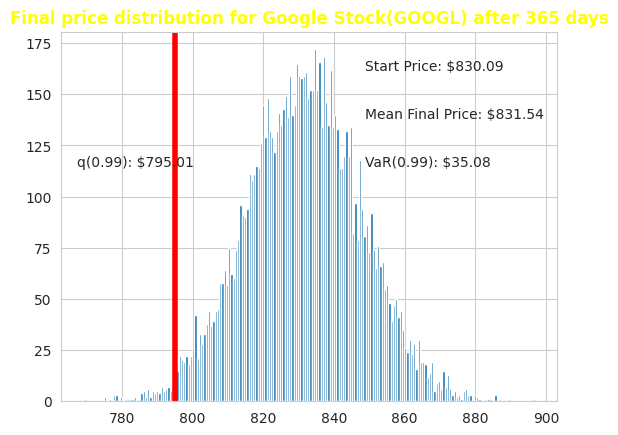

In [50]:
q = np.percentile(simulations, 1)

plt.hist(simulations, bins=200)

plt.figtext(0.6, 0.8, s='Start Price: $%.2f' % start_price)

plt.figtext(0.6, 0.7, s='Mean Final Price: $%.2f' % simulations.mean())

plt.figtext(0.6, 0.6, s='VaR(0.99): $%.2f' % (start_price - q))

plt.figtext(0.15, 0.6, s="q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title("Final price distribution for Google Stock(GOOGL) after %s days" % days, weight='bold', color='yellow')


Using the 1% empirical quantile from our Monte Carlo simulation, the 99% Value at Risk represents the potential loss on a single stock, based on its current price, under normal market conditions. This means there's a 99% chance the loss won't exceed this value over the forecast period.

##### Now lets plot remaining Stocks to estimate the VaR with our Monte Carlo Simulation.

In [51]:
start_price = 824.95

runs = 10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]

Text(0.5, 1.0, 'Final price distribution for Amazon Stock(AMZN) after 365 days')

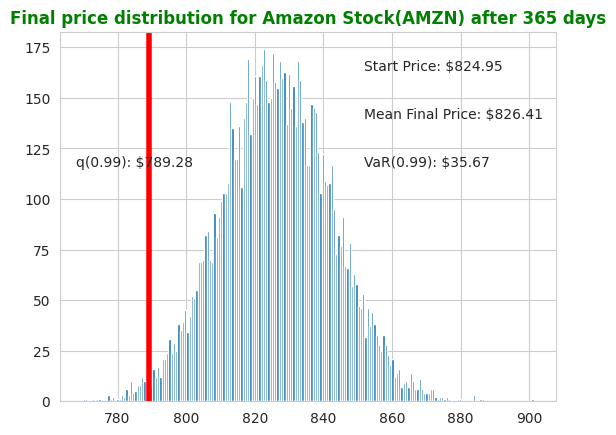

In [52]:
q = np.percentile(simulations, 1)

plt.hist(simulations, bins=200)

plt.figtext(0.6, 0.8, s='Start Price: $%.2f' % start_price)

plt.figtext(0.6, 0.7, s='Mean Final Price: $%.2f' % simulations.mean())

plt.figtext(0.6, 0.6, s='VaR(0.99): $%.2f' % (start_price - q))

plt.figtext(0.15, 0.6, s="q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title("Final price distribution for Amazon Stock(AMZN) after %s days" % days, weight='bold', color='green')

Based on the 1% empirical quantile from our Monte Carlo simulation of the current share price, the 99% Value at Risk per share is \$VAR, meaning you can expect to lose up to \$VAR on one share 99% of the time.

In [53]:
start_price = 117.10

runs = 10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]

Text(0.5, 1.0, 'Final price distribution for Apple Stock(AAPL) after 365 days')

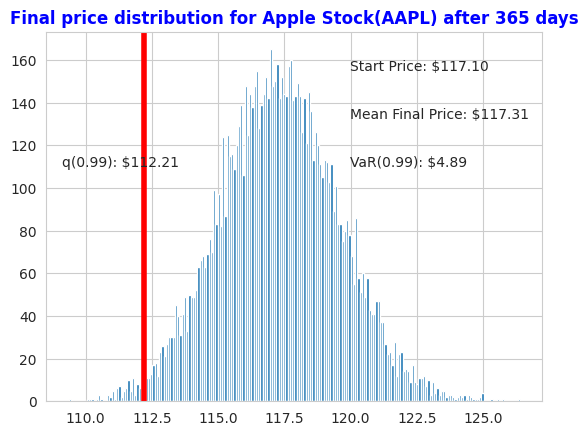

In [54]:
q = np.percentile(simulations, 1)

plt.hist(simulations, bins=200)

plt.figtext(0.6, 0.8, s='Start Price: $%.2f' % start_price)

plt.figtext(0.6, 0.7, s='Mean Final Price: $%.2f' % simulations.mean())

plt.figtext(0.6, 0.6, s='VaR(0.99): $%.2f' % (start_price - q))

plt.figtext(0.15, 0.6, s="q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title("Final price distribution for Apple Stock(AAPL) after %s days" % days, weight='bold', color='blue')

In [55]:
start_price = 59.94

runs = 10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]

Text(0.5, 1.0, 'Final price distribution for Microsoft Stock(MSFT) after 365 days')

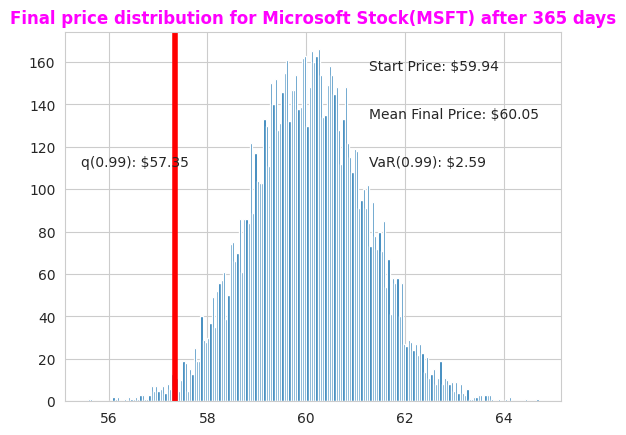

In [56]:
q = np.percentile(simulations, 1)

plt.hist(simulations, bins=200)

plt.figtext(0.6, 0.8, s='Start Price: $%.2f' % start_price)

plt.figtext(0.6, 0.7, s='Mean Final Price: $%.2f' % simulations.mean())

plt.figtext(0.6, 0.6, s='VaR(0.99): $%.2f' % (start_price - q))

plt.figtext(0.15, 0.6, s="q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title("Final price distribution for Microsoft Stock(MSFT) after %s days" % days, weight='bold', color='magenta')

#### Now jumping onto the prediction phase where the Bi-LSTM model is trained on the yfinance stock data.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
import tensorflow as tf
import os
import psutil

physical_devices = tf.config.list_physical_devices()
if not physical_devices:
    print("No devices found, using CPU.")
else:
    for device in physical_devices:
        print(f"Device: {device.device_type}, Name: {device.name}")

if tf.config.list_physical_devices('GPU'):
    print("\n✅ Using GPU")
    for gpu in tf.config.experimental.list_physical_devices('GPU'):
        details = tf.config.experimental.get_device_details(gpu)
        print(f"GPU Name: {details.get('device_name', 'Unknown')}")
else:
    print("\n✅ Using CPU")

print(f"\nCPU Cores: {os.cpu_count()}")
print(f"Physical Cores: {psutil.cpu_count(logical=False)}")
print(f"Logical Cores: {psutil.cpu_count(logical=True)}")

Device: CPU, Name: /physical_device:CPU:0
Device: GPU, Name: /physical_device:GPU:0

✅ Using GPU
GPU Name: Tesla T4

CPU Cores: 2
Physical Cores: 1
Logical Cores: 2


Checking for GPU availablity

In [58]:
def monte_carlo_simulation(stock_data, num_simulations=100, num_days=365):
    close_prices = stock_data['Close'].values
    log_returns = np.log(1 + stock_data['Close'].pct_change().dropna())
    mu = log_returns.mean()
    sigma = log_returns.std()
    last_price = close_prices[-1]

    simulated_prices = np.zeros((num_simulations, num_days))
    for i in range(num_simulations):
        daily_returns = np.random.normal(mu, sigma, num_days - 1)
        price_path = np.zeros(num_days)
        price_path[0] = last_price
        for j in range(1, num_days):
            price_path[j] = price_path[j - 1] * np.exp(daily_returns[j - 1])
        simulated_prices[i] = price_path
    return simulated_prices

Redefining the Monte Carlo Simulation to suit the integration with the RNN Prediction Model i.e. LSTM

In [59]:
def prepare_lstm_data_from_mc(simulated_prices, lookback_window, prediction_window):
    all_X = []
    all_y = []
    for path in simulated_prices:
        data = path.reshape(-1, 1)
        for i in range(len(data) - lookback_window - prediction_window + 1):
            all_X.append(data[i : i + lookback_window])
            all_y.append(data[i + lookback_window : i + lookback_window + prediction_window])
    return np.array(all_X), np.array(all_y)

In [60]:
def train_bi_lstm_from_mc(X_train, y_train, lookback_window, prediction_window, epochs=20, batch_size=32, validation_split=0.2):
    scaler_x = MinMaxScaler()
    X_train_scaled = scaler_x.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)

    scaler_y = MinMaxScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, prediction_window)).reshape(y_train.shape)

    model = Sequential([
        Bidirectional(LSTM(50, return_sequences=True, input_shape=(lookback_window, 1))),
        Dropout(0.2),
        Bidirectional(LSTM(50, return_sequences=False)),
        Dropout(0.2),
        Dense(prediction_window)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train_scaled, y_train_scaled, epochs=epochs, batch_size=batch_size, validation_split=validation_split)

    return model, scaler_x, scaler_y

The Bi-LSTM model is trained on the data from Monte Carlo simulation

In [61]:
def predict_future_bi_lstm_from_mc(model, last_real_prices, scaler_x, prediction_window, lookback_window):
    scaled_last_real_prices = scaler_x.transform(last_real_prices.reshape(-1, 1))
    input_sequence = scaled_last_real_prices.reshape(1, lookback_window, 1)
    predicted_scaled = model.predict(input_sequence)
    predicted_prices = scaler_x.inverse_transform(predicted_scaled.reshape(-1, 1)).flatten()
    return predicted_prices

Here comes Prediction of the Stock Prices begins

In [62]:
def predict_stock_price(stock_symbol):
    today = datetime.now()
    start_date = today - timedelta(days=365 * 5)

    data = yf.download(stock_symbol, start=start_date, end=today)
    if data.empty:
        print(f"Invalid stock symbol or no data available for {stock_symbol}.")
        return

    num_simulations = 200
    num_days_simulate = 365
    simulated_prices = monte_carlo_simulation(data, num_simulations, num_days_simulate)

    lookback_window = 60
    prediction_window = 180
    X_train, y_train = prepare_lstm_data_from_mc(simulated_prices, lookback_window, prediction_window)

    model, scaler_x, scaler_y = train_bi_lstm_from_mc(
        X_train, y_train, lookback_window, prediction_window, epochs=20, batch_size=128, validation_split=0.1
    )

    last_real_prices = data['Close'][-lookback_window:].values.reshape(-1, 1)

    future_predictions = predict_future_bi_lstm_from_mc(
        model, last_real_prices, scaler_x, prediction_window, lookback_window
    )

    future_dates = pd.date_range(start=today, periods=prediction_window)
    pred_df = pd.DataFrame({'Date': future_dates, 'Predicted Price': future_predictions})
    pred_df = pred_df.resample('ME', on='Date').mean()

    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Close'], label='Actual Prices')
    plt.plot(pred_df.index, pred_df['Predicted Price'], label='Monthly Predicted Prices', linestyle='dashed', marker='o')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.title(f'{stock_symbol} Monthly Stock Price Prediction')
    plt.legend()
    plt.grid(True)
    plt.show()

##### AAPL STOCK

[*********************100%***********************]  1 of 1 completed
<ipython-input-58-ebf7ea2d59b7>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_path[0] = last_price


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.0324 - val_loss: 0.0076
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0086 - val_loss: 0.0074
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0080 - val_loss: 0.0076
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0077 - val_loss: 0.0074
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0076 - val_loss: 0.0073
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0077 - val_loss: 0.0072
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0075 - val_loss: 0.0070
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0075 - val_loss: 0.0073
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 10/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0073 - val_loss: 0.0071
Epoch 11/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0073 - val_loss: 0.0071
Epoch 12/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/st

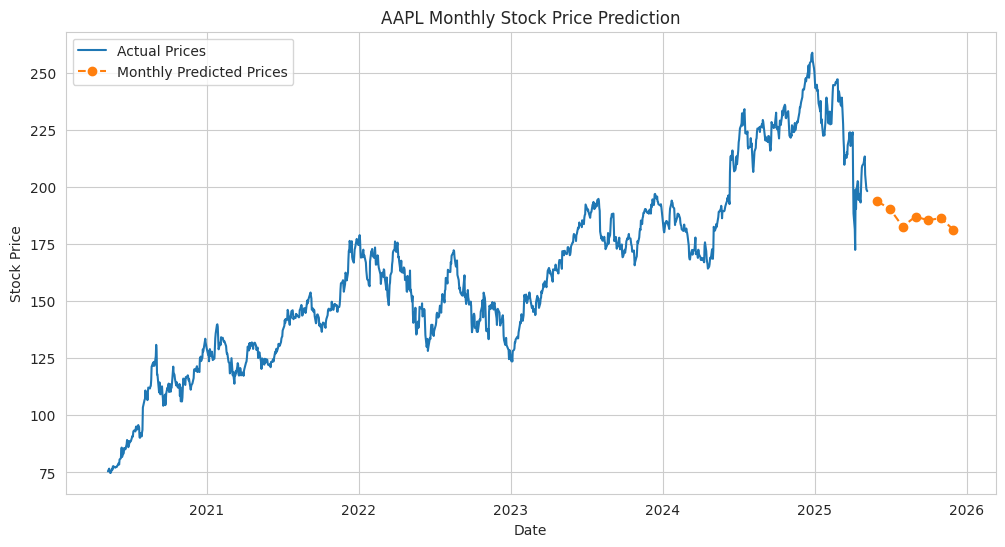

In [63]:
predict_stock_price('AAPL')

##### GOOGL STOCK

[*********************100%***********************]  1 of 1 completed
<ipython-input-58-ebf7ea2d59b7>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_path[0] = last_price


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0330 - val_loss: 0.0091
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0082 - val_loss: 0.0089
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0077 - val_loss: 0.0091
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0075 - val_loss: 0.0088
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0071 - val_loss: 0.0086
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0073 - val_loss: 0.0087
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0071 - val_loss: 0.0086
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0069 - val_loss: 0.0095
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0071 - val_loss: 0.0087
Epoch 10/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0071 - val_loss: 0.0088
Epoch 11/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0069 - val_loss: 0.0088
Epoch 12/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/ste

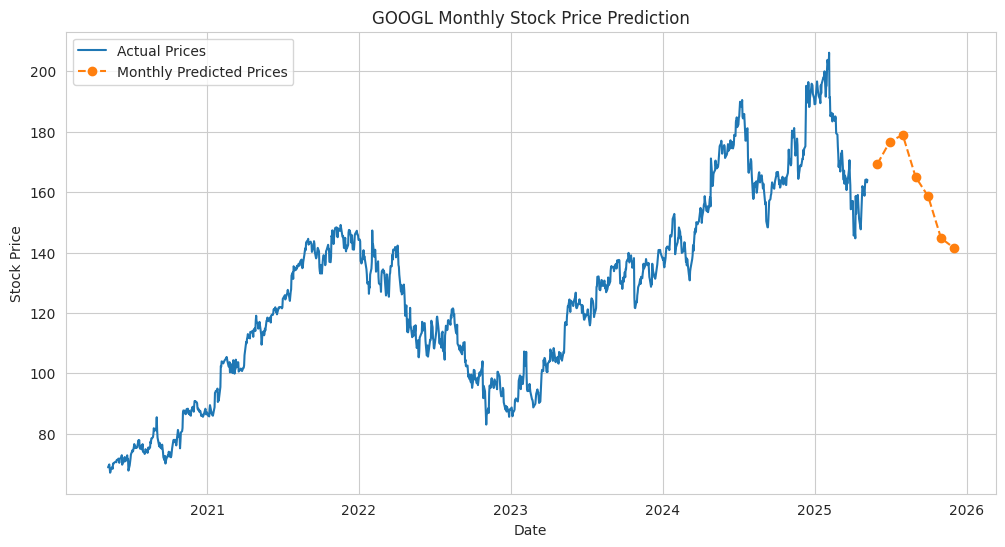

In [64]:
predict_stock_price('GOOGL')

##### AMZN STOCK

[*********************100%***********************]  1 of 1 completed
<ipython-input-58-ebf7ea2d59b7>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_path[0] = last_price
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0299 - val_loss: 0.0101
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0091 - val_loss: 0.0102
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0086 - val_loss: 0.0103
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0085 - val_loss: 0.0099
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0082 - val_loss: 0.0098
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0083 - val_loss: 0.0100
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0080 - val_loss: 0.0098
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0080 - val_loss: 0.0102
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0079 - val_loss: 0.0098
Epoch 10/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0080 - val_loss: 0.0099
Epoch 11/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0080 - val_loss: 0.0098
Epoch 12/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 

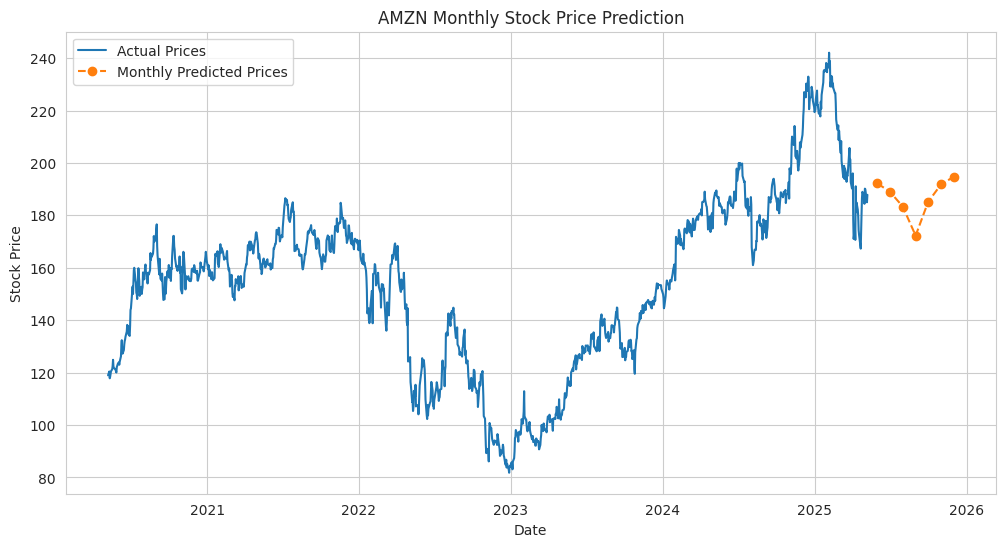

In [65]:
predict_stock_price('AMZN')

##### MSFT STOCK

[*********************100%***********************]  1 of 1 completed
<ipython-input-58-ebf7ea2d59b7>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_path[0] = last_price


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0345 - val_loss: 0.0073
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0084 - val_loss: 0.0075
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0078 - val_loss: 0.0064
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0076 - val_loss: 0.0071
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0076 - val_loss: 0.0070
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0073 - val_loss: 0.0070
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0073 - val_loss: 0.0068
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0072 - val_loss: 0.0069
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0071 - val_loss: 0.0065
Epoch 10/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0071 - val_loss: 0.0069
Epoch 11/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0070 - val_loss: 0.0065
Epoch 12/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/ste

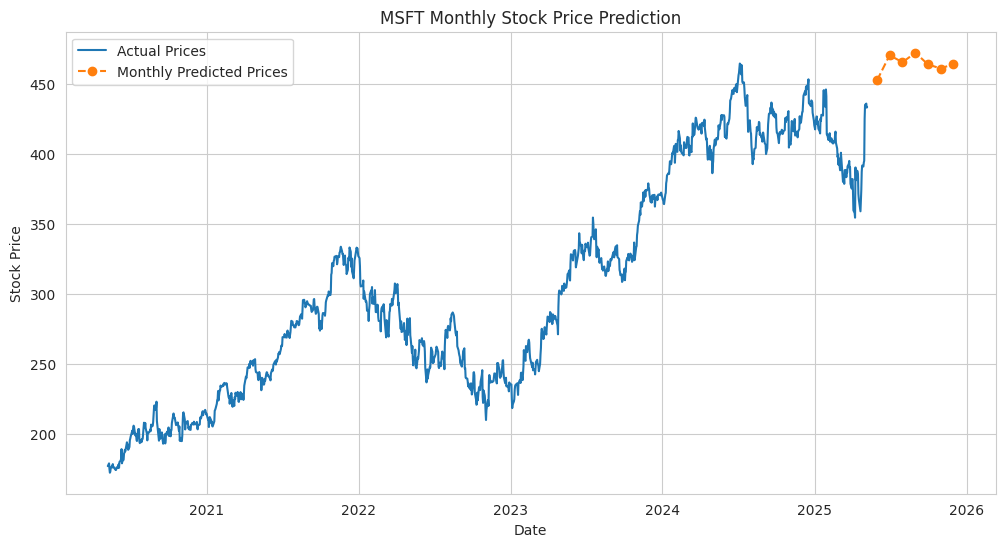

In [66]:
predict_stock_price('MSFT')

##### TSLA STOCK

[*********************100%***********************]  1 of 1 completed
<ipython-input-58-ebf7ea2d59b7>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_path[0] = last_price
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0114 - val_loss: 0.0032
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0053 - val_loss: 0.0028
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0053 - val_loss: 0.0032
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0051 - val_loss: 0.0034
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0051 - val_loss: 0.0031
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0050 - val_loss: 0.0030
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0050 - val_loss: 0.0034
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0049 - val_loss: 0.0031
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0050 - val_loss: 0.0035
Epoch 10/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0050 - val_loss: 0.0032
Epoch 11/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0047 - val_loss: 0.0034
Epoch 12/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step


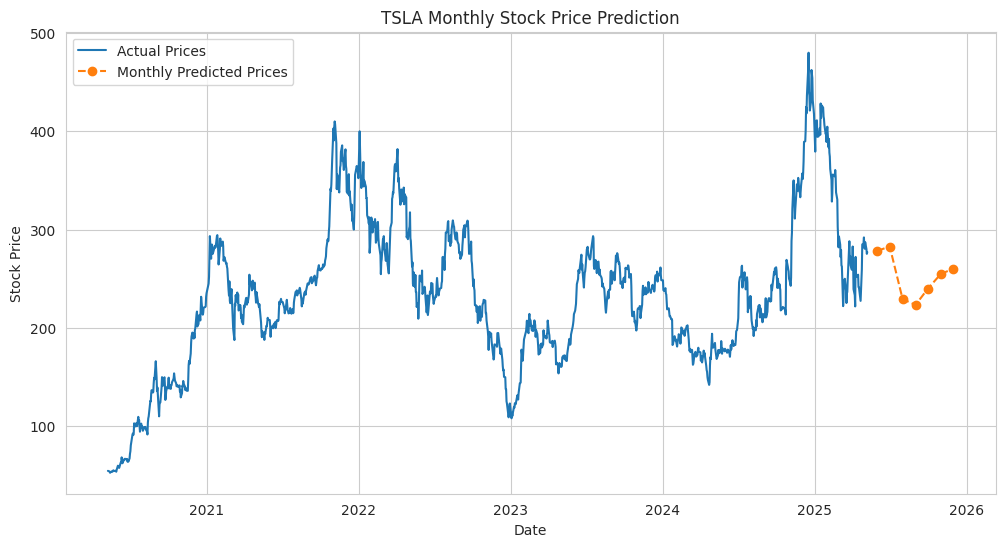

In [67]:
predict_stock_price('TSLA')